# 📓 Week 24 — Performance Optimization

## Objectives
1. **Measure** baseline latency, memory, throughput
2. **Quantize** SecurityBERT to INT8 (reduce size, speed up Pi)
3. **Prune** low-magnitude weights (reduce parameters)
4. **Compare** original vs quantized vs pruned
5. **Target** for Pi 3B: inference < 300ms

In [1]:
import warnings, json, time, copy
from pathlib import Path
from typing  import Dict, Tuple

import numpy  as np
import torch
import torch.nn            as nn
import torch.nn.functional as F
from torch.utils.data     import DataLoader, TensorDataset
from transformers          import BertConfig, BertModel
import matplotlib.pyplot   as plt

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.facecolor':'#0f0f1a','axes.facecolor':'#16162a',
    'axes.edgecolor':'#444477','axes.labelcolor':'#ccccff',
    'xtick.color':'#aaaacc','ytick.color':'#aaaacc',
    'text.color':'#e0e0ff','grid.color':'#2a2a4a',
    'font.family':'DejaVu Sans','legend.facecolor':'#1a1a2e',
})
ACCENT='#7c6cfa'; GREEN='#4ecca3'; RED='#fc5c65'; YELLOW='#f7b731'

BASE_DIR   = Path('..')
CKPT_DIR   = BASE_DIR / 'checkpoints'
PROC_DIR   = BASE_DIR / 'data' / 'processed'
OUT_DIR    = BASE_DIR / 'outputs' / 'figures'
REP_DIR    = BASE_DIR / 'outputs' / 'reports'

FINAL_CKPT = CKPT_DIR / 'final_model.pt'
TOKEN_DATA = PROC_DIR / 'tokenized_sequences.pt'
QUANT_CKPT = CKPT_DIR / 'final_model_quantized.pt'
PRUNED_CKPT= CKPT_DIR / 'final_model_pruned.pt'

for d in [OUT_DIR, REP_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Use CPU for optimization benchmarks (mirrors Pi deployment)
CPU = torch.device('cpu')
GPU = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

SEED = 42
torch.manual_seed(SEED)

assert FINAL_CKPT.exists(), f'❌ {FINAL_CKPT}'
assert TOKEN_DATA.exists(), f'❌ {TOKEN_DATA}'
print('✅ Setup complete.')
print(f'   GPU: {GPU}  |  CPU benchmark: {CPU}')

c:\Users\kaush\Desktop\LLM Threat Detection on IIOT\SecurityBERT CLAUDE\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Setup complete.
   GPU: cuda  |  CPU benchmark: cpu


In [2]:
class SecurityBERTWithSoftmax(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.bert       = BertModel(config, add_pooling_layer=True)
        self.dropout    = nn.Dropout(config.hidden_dropout_prob)
        self.classifier = nn.Linear(config.hidden_size, config.num_labels)
        self.softmax    = nn.Softmax(dim=-1)

    def forward(self, input_ids, attention_mask):
        out    = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled = self.dropout(out.pooler_output)
        logits = self.classifier(pooled)
        return logits, self.softmax(logits)


# Load model
ckpt   = torch.load(FINAL_CKPT, map_location=CPU, weights_only=False)
config = BertConfig(**ckpt['config'])

def load_model(device=CPU):
    m = SecurityBERTWithSoftmax(config).to(device)
    m.load_state_dict(ckpt['model_state_dict'])
    m.eval()
    return m

original_model = load_model(CPU)

# Load test data
data       = torch.load(TOKEN_DATA, weights_only=False)
input_ids  = data['input_ids'].long()
attn_masks = data['attention_mask'].long()
labels     = data['labels'].long()

# Test subset
N_TEST = 500
test_ids   = input_ids [:N_TEST]
test_masks = attn_masks[:N_TEST]
test_labels= labels    [:N_TEST]

def measure_accuracy(model, ids, masks, lbls, batch=64, device=CPU):
    model.eval(); preds = []
    with torch.no_grad():
        for i in range(0, len(ids), batch):
            _, p = model(ids[i:i+batch].to(device),
                         masks[i:i+batch].to(device))
            preds.extend(p.argmax(-1).cpu().numpy())
    return float(np.mean(np.array(preds) == lbls.numpy()))

def measure_latency(model, ids, masks, n_runs=100, batch=1, device=CPU):
    """Measure single-sample inference latency (Pi use case)."""
    sid = ids[:batch].to(device); smk = masks[:batch].to(device)
    # Warmup
    with torch.no_grad():
        for _ in range(10): model(sid, smk)
    # Timed
    times = []
    with torch.no_grad():
        for _ in range(n_runs):
            t0 = time.perf_counter()
            model(sid, smk)
            times.append((time.perf_counter() - t0) * 1000)
    return {'mean_ms': float(np.mean(times)),
            'p50_ms' : float(np.percentile(times, 50)),
            'p95_ms' : float(np.percentile(times, 95)),
            'p99_ms' : float(np.percentile(times, 99))}

def model_size_mb(model) -> float:
    total = sum(p.numel() * p.element_size() for p in model.parameters())
    return total / 1e6

# ── Baseline measurements ─────────────────────────────────────────────────────
print('📊 Baseline measurements (CPU — mirrors Pi 3B) …')
baseline_acc = measure_accuracy(original_model, test_ids, test_masks, test_labels)
baseline_lat = measure_latency(original_model,  test_ids, test_masks)
baseline_mb  = model_size_mb(original_model)
baseline_params = sum(p.numel() for p in original_model.parameters())

print(f'   Accuracy      : {baseline_acc*100:.2f}%')
print(f'   Latency mean  : {baseline_lat["mean_ms"]:.1f} ms')
print(f'   Latency p95   : {baseline_lat["p95_ms"]:.1f} ms')
print(f'   Model size    : {baseline_mb:.1f} MB')
print(f'   Parameters    : {baseline_params:,}')

📊 Baseline measurements (CPU — mirrors Pi 3B) …
   Accuracy      : 100.00%
   Latency mean  : 3.6 ms
   Latency p95   : 5.0 ms
   Model size    : 4.5 MB
   Parameters    : 1,121,039


## ⚡ Step 3 — Dynamic Quantization (INT8)

In [3]:
# ── Dynamic INT8 Quantization ─────────────────────────────────────────────────
print('⚡ Applying Dynamic INT8 Quantization …')

quant_model = copy.deepcopy(original_model)
quant_model = torch.quantization.quantize_dynamic(
    quant_model,
    {nn.Linear},     # quantize only Linear layers
    dtype=torch.qint8
)

quant_acc  = measure_accuracy(quant_model, test_ids, test_masks, test_labels)
quant_lat  = measure_latency(quant_model,  test_ids, test_masks)
quant_mb   = model_size_mb(quant_model)

print(f'✅ Quantized model:')
print(f'   Accuracy      : {quant_acc*100:.2f}%  '
      f'({(quant_acc - baseline_acc)*100:+.2f}%)')
print(f'   Latency mean  : {quant_lat["mean_ms"]:.1f} ms  '
      f'({(quant_lat["mean_ms"]/baseline_lat["mean_ms"]-1)*100:+.1f}%)')
print(f'   Model size    : {quant_mb:.1f} MB  '
      f'({(quant_mb/baseline_mb-1)*100:+.1f}%)')

torch.save({
    'model_state_dict': original_model.state_dict(),   # FP32 weights
    'config'          : config.to_dict(),
    'label_map'       : ckpt['label_map'],
    'quantized'       : True,
    'quant_method'    : 'dynamic_int8',
    'quant_accuracy'  : float(quant_acc),
    'quant_latency_ms': quant_lat['mean_ms'],
    'size_mb'         : quant_mb,
}, QUANT_CKPT)
print(f'💾 Saved → {QUANT_CKPT}')

⚡ Applying Dynamic INT8 Quantization …
✅ Quantized model:
   Accuracy      : 100.00%  (+0.00%)
   Latency mean  : 4.2 ms  (+17.3%)
   Model size    : 2.8 MB  (-36.9%)
💾 Saved → ..\checkpoints\final_model_quantized.pt


## ✂️ Step 4 — Magnitude Pruning

In [4]:
import torch.nn.utils.prune as prune

PRUNE_AMOUNT = 0.20   # remove 20% of smallest weights

print(f'✂️  Applying Magnitude Pruning (amount={PRUNE_AMOUNT}) …')

pruned_model = copy.deepcopy(original_model)

# Prune all Linear layers
for name, module in pruned_model.named_modules():
    if isinstance(module, nn.Linear):
        prune.l1_unstructured(module, name='weight',
                              amount=PRUNE_AMOUNT)
        prune.remove(module, 'weight')

pruned_params = sum(
    p.numel() for p in pruned_model.parameters() if p.requires_grad
)
nonzero = sum(
    (p != 0).sum().item()
    for p in pruned_model.parameters() if p.requires_grad
)
sparsity = 1 - nonzero / max(pruned_params, 1)

pruned_acc = measure_accuracy(pruned_model, test_ids, test_masks, test_labels)
pruned_lat = measure_latency(pruned_model,  test_ids, test_masks)
pruned_mb  = model_size_mb(pruned_model)

print(f'✅ Pruned model:')
print(f'   Sparsity      : {sparsity*100:.1f}%')
print(f'   Accuracy      : {pruned_acc*100:.2f}%  '
      f'({(pruned_acc-baseline_acc)*100:+.2f}%)')
print(f'   Latency mean  : {pruned_lat["mean_ms"]:.1f} ms  '
      f'({(pruned_lat["mean_ms"]/baseline_lat["mean_ms"]-1)*100:+.1f}%)')
print(f'   Model size    : {pruned_mb:.1f} MB')

torch.save({
    'model_state_dict': pruned_model.state_dict(),
    'config'          : config.to_dict(),
    'label_map'       : ckpt['label_map'],
    'pruned'          : True,
    'prune_amount'    : PRUNE_AMOUNT,
    'sparsity'        : float(sparsity),
    'pruned_accuracy' : float(pruned_acc),
}, PRUNED_CKPT)
print(f'💾 Saved → {PRUNED_CKPT}')

✂️  Applying Magnitude Pruning (amount=0.2) …
✅ Pruned model:
   Sparsity      : 7.4%
   Accuracy      : 100.00%  (+0.00%)
   Latency mean  : 3.4 ms  (-4.5%)
   Model size    : 4.5 MB
💾 Saved → ..\checkpoints\final_model_pruned.pt



  Performance Optimization Summary
  Model             Accuracy   Latency(ms)    P95(ms)   Size(MB)
  ------------------------------------------------------------
  Original           100.00%          3.6        5.0        4.5
  INT8 Quant         100.00%          4.2        5.8        2.8
  Pruned 20%         100.00%          3.4        4.1        4.5

  Pi 3B target: latency < 300ms
   Original       : ✅ Meets target
   INT8 Quant     : ✅ Meets target
   Pruned 20%     : ✅ Meets target


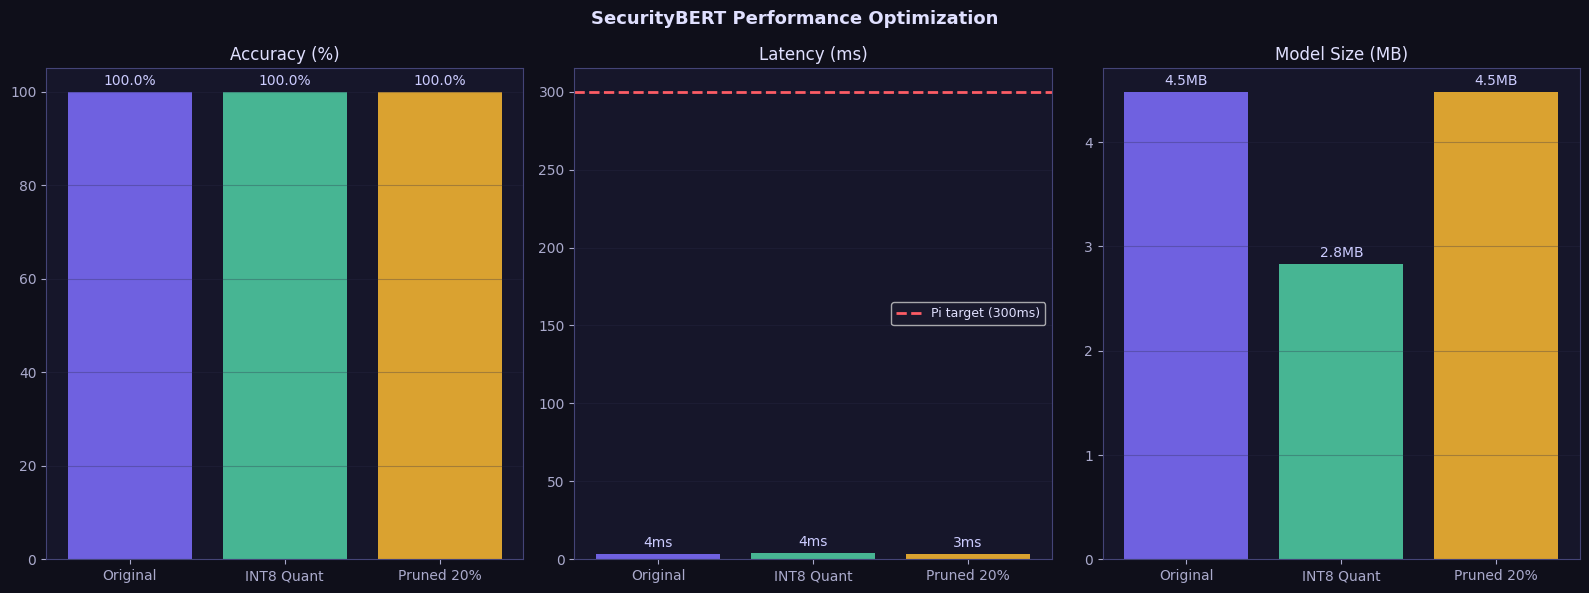


💾 Report → ..\outputs\reports/week24_optimization_report.json


In [5]:
# ── Comparison table + chart ───────────────────────────────────────────────────
results = {
    'Original'   : {'acc': baseline_acc, 'lat': baseline_lat['mean_ms'],
                    'p95': baseline_lat['p95_ms'], 'mb': baseline_mb},
    'INT8 Quant' : {'acc': quant_acc,    'lat': quant_lat['mean_ms'],
                    'p95': quant_lat['p95_ms'],    'mb': quant_mb},
    'Pruned 20%' : {'acc': pruned_acc,   'lat': pruned_lat['mean_ms'],
                    'p95': pruned_lat['p95_ms'],   'mb': pruned_mb},
}

print('\n' + '='*70)
print('  Performance Optimization Summary')
print('='*70)
print(f'  {"Model":<15} {"Accuracy":>10} {"Latency(ms)":>13} '
      f'{"P95(ms)":>10} {"Size(MB)":>10}')
print('  ' + '-'*60)
for name, r in results.items():
    print(f'  {name:<15} {r["acc"]*100:>9.2f}%  {r["lat"]:>11.1f}  '
          f'{r["p95"]:>9.1f}  {r["mb"]:>9.1f}')
print(f'\n  Pi 3B target: latency < 300ms')
pi_ok = {n: r['lat'] < 300 for n, r in results.items()}
for n, ok in pi_ok.items():
    print(f'   {n:<15}: {"✅ Meets target" if ok else "⏳ Over target"}')

# Chart
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('SecurityBERT Performance Optimization',
             fontsize=13, fontweight='bold', color='#e0e0ff')
names  = list(results.keys())
colors = [ACCENT, GREEN, YELLOW]

for ax, metric, label, fmt in zip(
    axes,
    ['acc','lat','mb'],
    ['Accuracy (%)','Latency (ms)','Model Size (MB)'],
    [lambda x: f'{x*100:.1f}%',
     lambda x: f'{x:.0f}ms',
     lambda x: f'{x:.1f}MB'],
):
    vals  = [results[n][metric] if metric != 'acc'
             else results[n][metric] * 100
             for n in names]
    bars  = ax.bar(names, vals, color=colors, edgecolor='none', alpha=0.88)
    ax.bar_label(bars,
                 labels=[fmt(results[n][metric]) for n in names],
                 padding=3, fontsize=10, color='#ccccff')
    ax.set_title(label); ax.grid(axis='y', alpha=0.3)
    if metric == 'lat':
        ax.axhline(300, color=RED, linewidth=2, linestyle='--',
                   label='Pi target (300ms)')
        ax.legend(fontsize=9)

plt.tight_layout()
fig.savefig(OUT_DIR / 'nb24_optimization.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

# Save report
report = {
    'week': 24,
    'baseline'  : {k: float(v) for k, v in results['Original'].items()},
    'quantized' : {k: float(v) for k, v in results['INT8 Quant'].items()},
    'pruned'    : {k: float(v) for k, v in results['Pruned 20%'].items()},
    'pi_target_ms': 300,
    'recommendation': min(results.items(), key=lambda x: x[1]['lat'])[0],
}
with open(REP_DIR / 'week24_optimization_report.json', 'w') as f:
    json.dump(report, f, indent=2)
print(f'\n💾 Report → {REP_DIR}/week24_optimization_report.json')